In [3]:

# Import libraries
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from src.clustering_library.__init__ import DataCleaner, compute_rfm, DataVisualizer
from src.notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
file_path = r"C:\Users\ACER\Documents\data_project\data\raw\Online Retail.xlsx"
out_path = "../data/processed/cleaned_data.csv"

In [5]:

cleaner = DataCleaner(file_path)
cleaner.load_data()
cleaner.clean_data()
cleaner.transform_datetime()



2026-08-04 13:00:30,571 - INFO - Đang tải dữ liệu từ: C:\Users\ACER\Documents\data_project\data\raw\Online Retail.xlsx
2026-08-04 13:00:59,344 - INFO - Dataset shape: (541909, 8)
2026-08-04 13:00:59,344 - INFO - Number of records: 541,909 rows
2026-08-04 13:00:59,345 - INFO - Đang tiến hành làm sạch dữ liệu...
2026-08-04 13:00:59,707 - INFO - Làm sạch hoàn tất! Kích thước dữ liệu UK: (354321, 9)
2026-08-04 13:00:59,877 - INFO - Đã tạo xong các đặc trưng thời gian (DayOfWeek, HourOfDay)!


In [7]:
cleaner.save_to_csv(output_path=out_path)


2026-08-04 13:01:26,704 - INFO - Đang lưu dữ liệu đã làm sạch vào: ..\data\processed\cleaned_data.csv
2026-08-04 13:01:28,067 - INFO - Lưu file thành công!


WindowsPath('../data/processed/cleaned_data.csv')

In [8]:
visualizer = DataVisualizer()

In [9]:
df = cleaner.load_data()

2026-08-04 13:01:35,391 - INFO - Đang tải dữ liệu từ: C:\Users\ACER\Documents\data_project\data\raw\Online Retail.xlsx
2026-08-04 13:02:06,099 - INFO - Dataset shape: (541909, 8)
2026-08-04 13:02:06,102 - INFO - Number of records: 541,909 rows


In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom


In [11]:
print("-----Dataset Overview------")
print(f" - Size: {df.shape[1]}, Length: {len(df)}")
print(f" - Missing values: {df.isnull().sum().sum()}")
print(f" - Unique customers: {df['CustomerID'].nunique()}")
df.info()

-----Dataset Overview------
 - Size: 8, Length: 541909
 - Missing values: 136534
 - Unique customers: 4372
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 33.1+ MB


In [12]:
df_uk = cleaner.clean_data()

2026-08-04 13:02:14,554 - INFO - Đang tiến hành làm sạch dữ liệu...
2026-08-04 13:02:14,892 - INFO - Làm sạch hoàn tất! Kích thước dữ liệu UK: (354321, 9)


In [13]:
df_uk.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34


In [14]:
print("-----Dataset Overview------")
print(f" - Size: {df_uk.shape[1]}")
print(f" - Missing values: {df_uk.isnull().sum().sum()}")
print(f" - Unique customers: {df_uk['CustomerID'].nunique()}")
df_uk.info()

-----Dataset Overview------
 - Size: 9
 - Missing values: 0
 - Unique customers: 3920
<class 'pandas.DataFrame'>
Index: 354321 entries, 0 to 541893
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    354321 non-null  object        
 1   StockCode    354321 non-null  object        
 2   Description  354321 non-null  object        
 3   Quantity     354321 non-null  int64         
 4   InvoiceDate  354321 non-null  datetime64[us]
 5   UnitPrice    354321 non-null  float64       
 6   CustomerID   354321 non-null  str           
 7   Country      354321 non-null  str           
 8   TotalPrice   354321 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 27.0+ MB


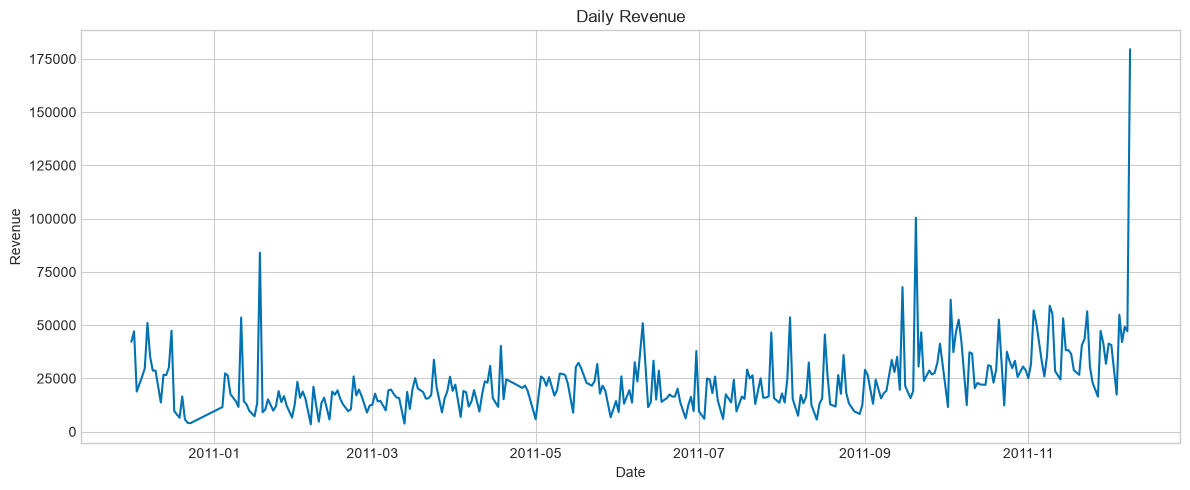

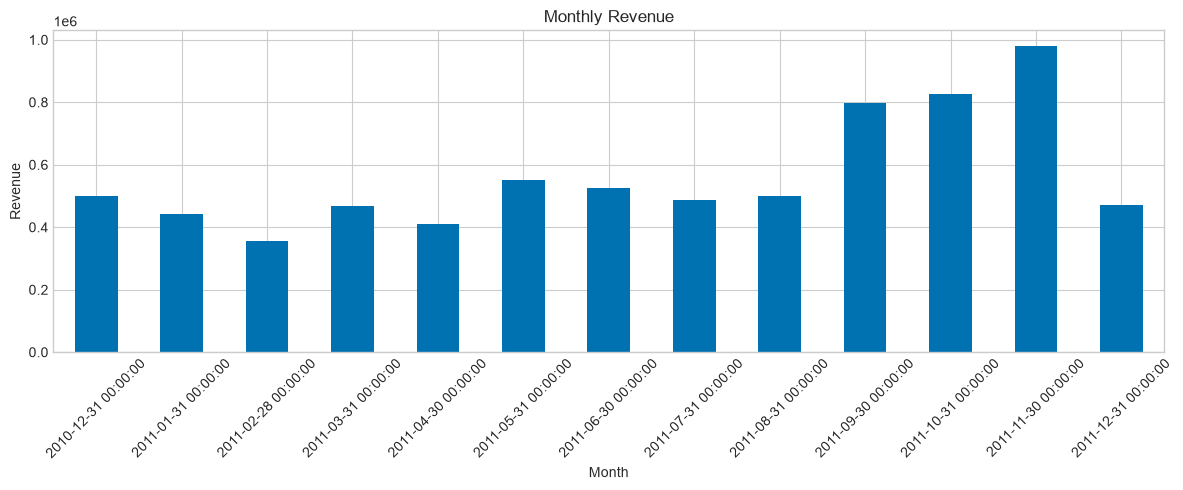

In [15]:
visualizer.plot_revenue_over_time(df_uk)

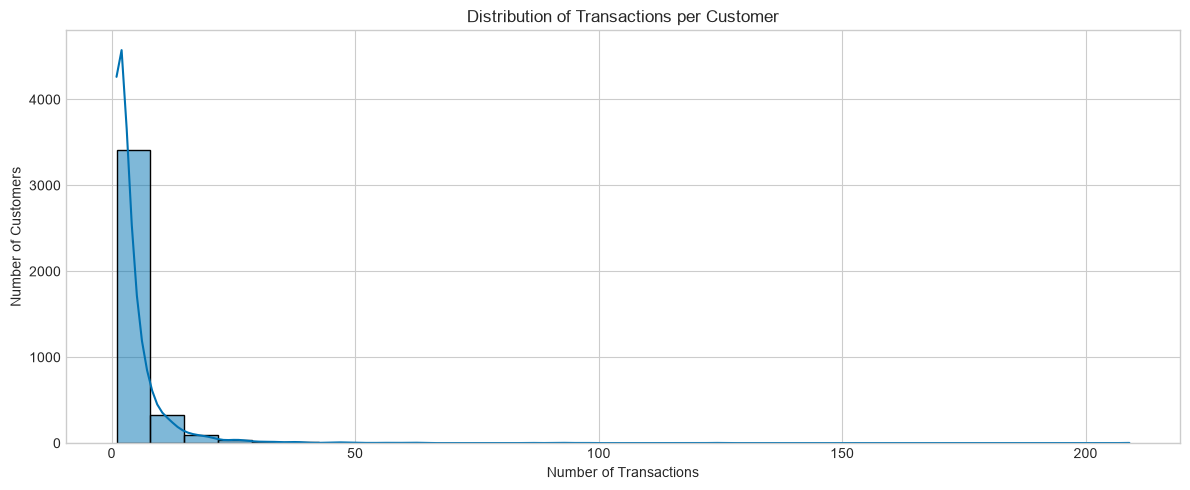

In [19]:
visualizer.plot_customer_distribution(df_uk)

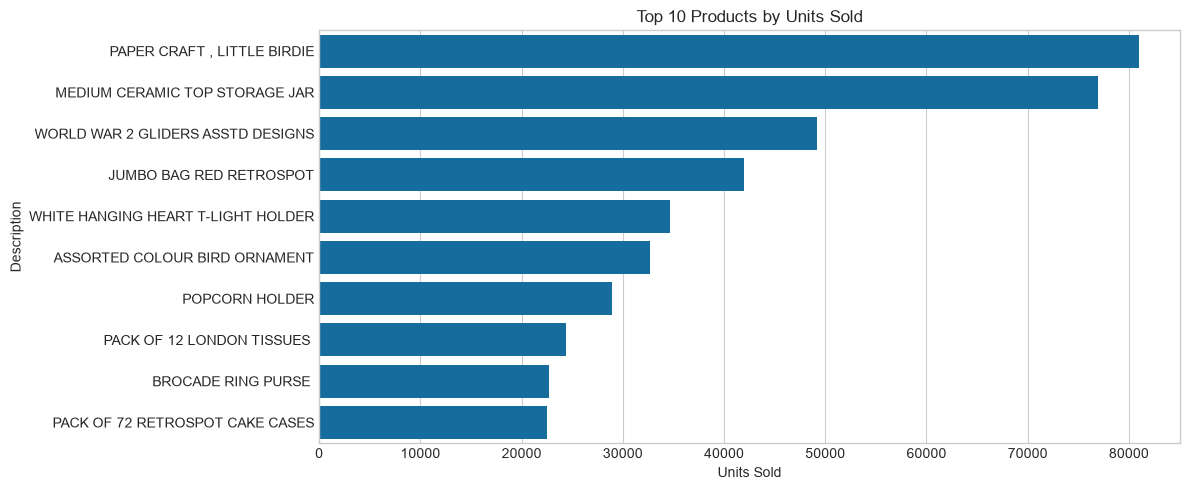

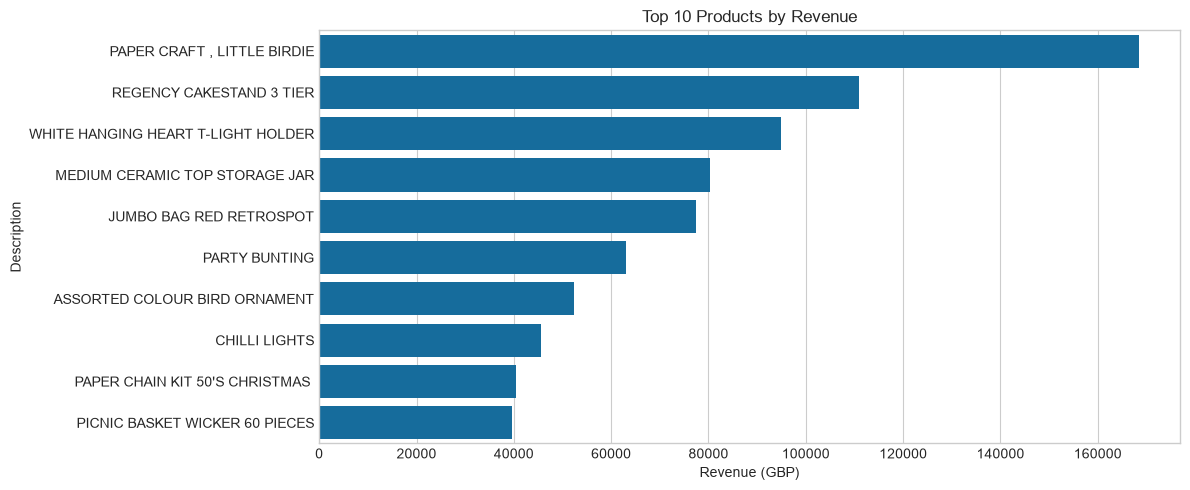

In [22]:
visualizer.plot_product_analysis(df_uk)

In [25]:
df_uk

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,015804,United Kingdom,23.40
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,013113,United Kingdom,23.60
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,013113,United Kingdom,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,013113,United Kingdom,214.80


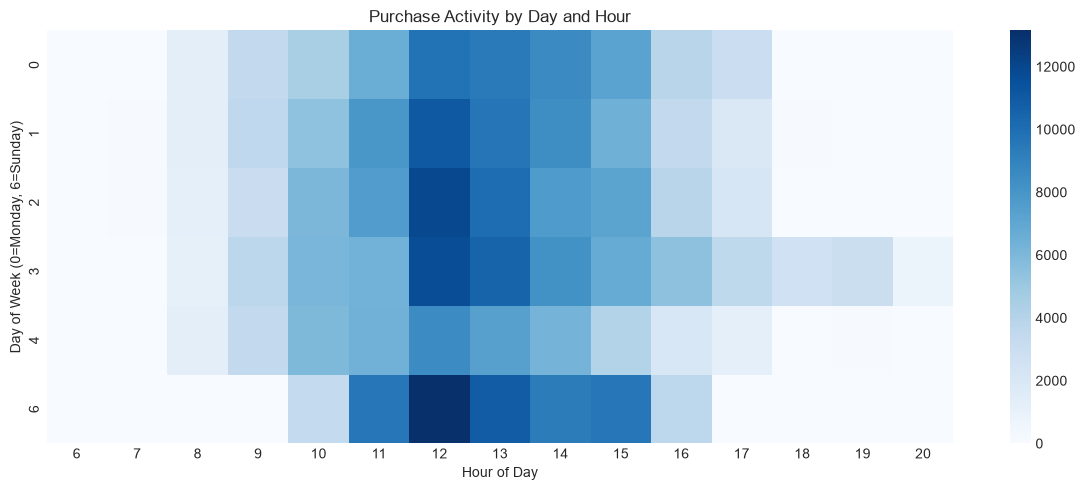

In [26]:
visualizer.plot_time_patterns(df_uk)

----RFM Analysis----
 - Mean Recency: 92 days
 - Mean frequency: 4.2 transactions
 - Mean Monetary: 1864.39


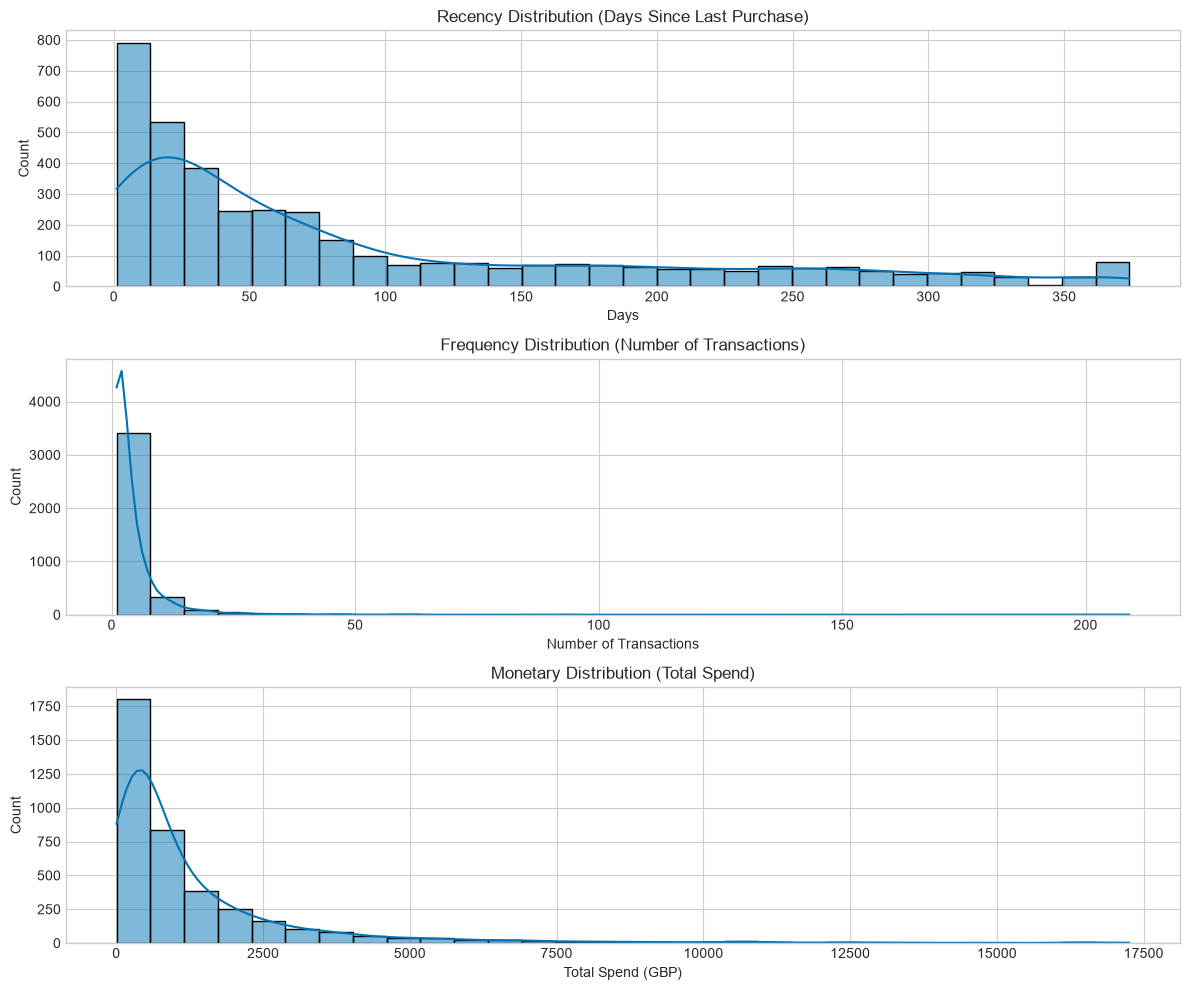

In [34]:
rfm_data = compute_rfm(df_uk).set_index("CustomerID")

print('----RFM Analysis----')
print(f" - Mean Recency: {rfm_data['Recency'].mean():.0f} days")
print(f" - Mean frequency: {rfm_data['Frequency'].mean():.1f} transactions")
print(f" - Mean Monetary: {rfm_data['Monetary'].mean():.2f}")


visualizer.plot_rfm(rfm_data)

In [35]:
print("Data saved successfully:")
print("- File: cleaned_uk_data.csv")
print(f"- Size: {df_uk.shape[0]:,} rows")
print("- Ready for feature engineering")

Data saved successfully:
- File: cleaned_uk_data.csv
- Size: 354,321 rows
- Ready for feature engineering
